# Selection, read latency, and tile size

Paper greedy and Saturation receive the same activation vector and requested row budget $R$. We compare selection-to-read time and retained importance, then ask whether Saturation benefits from tiles smaller or larger than its profile-derived size $s$.

This is a projection-level experiment using dense activation traces and a random weight-sized file. Retained importance is a proxy, not model accuracy. All experiment-specific selection code, tuning rules, timing boundaries and analysis are given here. Input data are `../01/block_estimates.csv` and `../02/activation_traces.npz`; `vlmflash` supplies the shared native reader and Paper implementation as a library dependency.

Run from this notebook's directory. `RUN_BENCHMARK = False` reports saved measurements; `True` retunes and measures all nine methods on the target SSD, requiring CUDA, PyTorch and a C++ compiler. An older two-method recording remains readable, but cannot establish a preferred tile scale. Rerun after changing inputs or settings.

In [17]:
from pathlib import Path
from time import perf_counter_ns
from tempfile import TemporaryDirectory
import fcntl, json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

PROFILE, TRACE = Path("../01/block_estimates.csv"), Path("../02/activation_traces.npz")
UPSTREAM = Path("../../vlm-flash")
RESULTS, ENVIRONMENT = Path("measured_results.csv"), Path("measured_environment.json")
RUN_BENCHMARK = True
MAX_TRACES_PER_SHAPE = 32
FRACTIONS = np.arange(3, 11) / 10
WARMUP, REPEATS, THREADS = 3, 30, 6
PAPER, TILE = "Paper greedy (GPU sort)", "Saturation"
SCALES = np.arange(1, 9) / 4
SCALE_METHODS = {TILE if a == 1 else f"Saturation ({a:g}s)": float(a) for a in SCALES}

## Budget and retained importance

For a projection with $N$ rows, fraction $f$ gives $R=\max(1,\lfloor fN\rfloor)$. Archived importance is the mean absolute input activation, $v_i=\operatorname{mean}_{\rm batch,token}|x_i|$, normalized to mean one. A binary mask $M$ retains

$$q(M)=\frac{\sum_i v_iM_i}{\sum_i v_i},\qquad
\operatorname{fill}(M)=\frac{\sum_i M_i}{R}.$$

Paper may underfill; Saturation fills $R$. At $R=N$, both bypass selection. Zero-total importance leaves $q$ undefined. Up to `MAX_TRACES_PER_SHAPE` traces are sampled at evenly spaced archive positions within each shape.

In [18]:
if RUN_BENCHMARK:
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]]} for t in manifest["traces"]]
    groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
    traces = [g[i] for g in groups for i in np.linspace(0, len(g)-1,
              min(len(g), MAX_TRACES_PER_SHAPE or len(g)), dtype=int)]
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    curve = pd.read_csv(PROFILE).groupby("size_kib").latency_ms.median().sort_index()
    assert np.isfinite(curve).all() and (curve > 0).all()
    boundary, ceiling = float((curve / curve.index).idxmin()), float(curve.index.max())

## Cost and tile scale

The median profile defines $T(z)$, the cost in milliseconds of a $z$ KiB read. Costs interpolate between measured sizes, floor smaller reads at the minimum size, and extend the upper endpoint linearly. A mask's modeled cost sums $T$ over maximal selected runs; adjacent tiles merge. This serial cost model chooses masks, while the measured reader uses multiple threads.

For $N\times d$ weights, one row occupies $w=d\,\text{bytes per weight}/1024$ KiB. Define

$$s=\min\arg\min_{z\text{ in profile}}\frac{T(z)}z,\qquad
B_\alpha=\left\lceil\frac{\alpha s}{w}\right\rceil,\qquad
\alpha\in\{0.25,0.5,0.75,1,1.25,1.5,1.75,2\}.$$

Thus $s$ is the most efficient measured read size, and $B_\alpha$ is the tile width in whole rows. The realized width is $B_\alpha w$ KiB; rounding can make different scales identical. Small tiles offer finer importance selection, while large tiles can reduce fragmentation. Neither observation determines the fastest selection-to-read time. We measure every scale separately, without choosing a scale for each trace after seeing its result.

## The shared tile selector

Only $B$ changes across scales. At offsets $0$ and $\lfloor B/2\rfloor$, take the $\lfloor R/B\rfloor$ highest-importance full tiles, then the best disjoint interval of length $R\bmod B$. Discard an infeasible offset and keep the mask with greater importance per modeled cost. If $R<B$, take the best length-$R$ interval. At $R=N$, bypass selection for every method.

The complete C++ implementation occupies one source cell below. `%%writefile` writes it to a temporary build input; no separately maintained selector file is needed. Compilation is outside timing. The helpers validate inputs, break score ties by index, and score merged runs.

In [19]:
source_dir = TemporaryDirectory(prefix="selection03-")
tile_source_path = Path(source_dir.name) / "tiles.cpp"

In [20]:
%%writefile $tile_source_path
#include <torch/extension.h>
#include <algorithm>
#include <cmath>
#include <numeric>
#include <tuple>
#include <vector>

using Result = std::tuple<torch::Tensor, double, double>;

namespace {
void check(const torch::Tensor& v, int64_t R, const torch::Tensor& T) {
    TORCH_CHECK(v.device().is_cpu() && v.scalar_type() == torch::kFloat32
                && v.dim() == 1 && v.is_contiguous(), "v must be contiguous CPU float32");
    TORCH_CHECK(0 <= R && R <= v.numel(), "R must be between 0 and N");
    TORCH_CHECK(T.device().is_cpu() && T.scalar_type() == torch::kFloat64
                && T.dim() == 1 && T.is_contiguous() && T.numel() > v.numel(),
                "T must be contiguous CPU float64 with N+1 entries");
}

// Select the largest k scores, breaking ties by the original index.
// Their internal order is irrelevant because the chosen tiles are disjoint.
std::vector<int64_t> largest(const std::vector<double>& scores, int64_t k) {
    std::vector<int64_t> order(scores.size());
    std::iota(order.begin(), order.end(), 0);
    auto better = [&](int64_t a, int64_t b) {
        return scores[a] != scores[b] ? scores[a] > scores[b] : a < b;
    };
    if (k > 0 && k < static_cast<int64_t>(order.size()))
        std::nth_element(order.begin(), order.begin() + k, order.end(), better);
    order.resize(k);
    return order;
}

// Report the selected importance and the cost of maximal, merged runs.
Result summarize(const torch::Tensor& v, torch::Tensor mask, const torch::Tensor& T) {
    const auto* values = v.data_ptr<float>();
    const auto* selected = mask.data_ptr<uint8_t>();
    const auto* cost = T.data_ptr<double>();
    double importance = 0, latency = 0;
    int64_t length = 0;
    for (int64_t i = 0; i < v.numel(); ++i) {
        if (selected[i]) {
            importance += values[i];
            ++length;
        } else {
            latency += cost[length];
            length = 0;
        }
    }
    return {mask, importance, latency + cost[length]};
}
}  // namespace

Result tiles(torch::Tensor v, int64_t R, torch::Tensor T, int64_t B) {
    check(v, R, T);
    TORCH_CHECK(B >= 1, "tile width B must be positive");
    const int64_t n = v.numel();
    const auto* values = v.data_ptr<float>();
    std::vector<double> prefix(n + 1, 0);
    for (int64_t i = 0; i < n; ++i) prefix[i + 1] = prefix[i] + values[i];

    if (R < B) {
        int64_t start = 0;
        for (int64_t i = 1; i + R <= n; ++i)
            if (prefix[i + R] - prefix[i] > prefix[start + R] - prefix[start]) start = i;
        auto mask = torch::zeros({n}, torch::kUInt8);
        std::fill_n(mask.data_ptr<uint8_t>() + start, R, uint8_t{1});
        return summarize(v, mask, T);
    }

    const int64_t k = R / B, residual = R % B;
    Result best;
    double best_ratio = -1;
    for (int64_t offset : {int64_t{0}, B / 2}) {
        std::vector<int64_t> starts;
        std::vector<double> scores;
        for (int64_t start = offset; start + B <= n; start += B) {
            starts.push_back(start);
            scores.push_back(prefix[start + B] - prefix[start]);
        }
        if (static_cast<int64_t>(starts.size()) < k) continue;
        auto mask = torch::zeros({n}, torch::kUInt8);
        auto* selected = mask.data_ptr<uint8_t>();
        for (auto j : largest(scores, k))
            std::fill_n(selected + starts[j], B, uint8_t{1});

        if (residual) {
            std::vector<int64_t> occupied(n + 1, 0);
            for (int64_t i = 0; i < n; ++i) occupied[i + 1] = occupied[i] + selected[i];
            int64_t start = -1;
            double score = -1;
            for (int64_t i = 0; i + residual <= n; ++i) {
                double candidate = prefix[i + residual] - prefix[i];
                if (occupied[i + residual] == occupied[i] && candidate > score) {
                    start = i;
                    score = candidate;
                }
            }
            if (start < 0) continue;
            std::fill_n(selected + start, residual, uint8_t{1});
        }
        auto result = summarize(v, mask, T);
        double ratio = std::get<1>(result) / std::get<2>(result);
        if (ratio > best_ratio) {
            best_ratio = ratio;
            best = result;
        }
    }
    TORCH_CHECK(best_ratio >= 0, "no exact-R tiling was feasible");
    return best;
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
    m.def("tiles", &tiles);
}

Writing /tmp/selection03-kqzlvzrl/tiles.cpp


## Native dependencies

Paper generates windows at several sizes, sorts importance/cost scores on the GPU, then accepts non-overlapping windows on the CPU while they fit $R$. It may underfill. The shared reader merges adjacent rows and returns their bytes on the CPU using direct I/O. These library calls are used unchanged for every tile scale; the tile selector above stays on the CPU.

In [21]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path.insert(0, str((UPSTREAM / "src").resolve()))
    import vlmflash
    from vlmflash._native import native
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    assert torch.cuda.is_available(), "CUDA is required for Paper's GPU sort."
    reader = native()
    assert reader is not None, "Native reader required."
    selectors = load("vlmflash_selection03_notebook", [str(tile_source_path)],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)
    table = vlmflash.LatencyTable(curve.to_dict())

## Paper window tuning

The Appendix H procedure is evaluated on each shape: random importance with seed 0, sparsity 0.1, 30 repetitions, and start/stride caps from 4 to 64 KiB in 4 KiB steps. Equivalent row-quantized configurations are tested once. Candidate widths advance by the start width in rows and stop below $\lfloor(z_{\max}+1)/w\rfloor$, where $z_{\max}$ is the largest profiled size; their stride is capped by the tuned stride.

Tuning includes the library wrapper's setup and selects the finest configuration within 1.6 ms, then within 2 ms if needed. If none meets 2 ms, it takes the fastest measured configuration. These tuning times differ in scope from the prepared calls used in the comparison.

In [22]:
def tuning_trials(n, d):
    w, seen = d * weight_bytes / 1024, set()
    values = torch.rand(n, generator=torch.Generator().manual_seed(0)) + 0.5
    for start in range(4, 68, 4):
        for jump in range(4, 68, 4):
            row_config = (max(1, int(start / w)), max(1, int(jump / w)))
            if row_config in seen:
                continue
            seen.add(row_config)
            params = vlmflash.ChunkParams(start_kb=start, jump_cap_kb=jump)
            select = lambda: vlmflash.select_chunks(values, n-int(n*0.1), w, table, params, impl="native")
            try:
                select()
            except ValueError:
                continue
            times = []
            for _ in range(30):
                begin = perf_counter_ns()
                select()
                times.append((perf_counter_ns()-begin)/1e6)
            yield dict(start_kb=start, jump_cap_kb=jump, overhead_ms=round(float(np.median(times)), 3))

The tuning result records the chosen parameters and the number of configurations inside the 2 ms budget.

In [23]:
def tune_windows():
    tuned = {}
    for shape in sorted({t["shape"] for t in traces}):
        trials = list(tuning_trials(*map(int, shape.split("x"))))
        assert trials, f"No evaluable Paper windows for {shape}."
        within = [t for t in trials if t["overhead_ms"] <= 2]
        pool = [t for t in within if t["overhead_ms"] <= 1.6] or within
        best = (min(pool, key=lambda t: (t["start_kb"] + t["jump_cap_kb"], t["start_kb"]))
                if pool else min(trials, key=lambda t: t["overhead_ms"]))
        tuned[shape] = dict(best=best, num_feasible=len(within), num_evaluated=len(trials))
        print(f"{shape}: {best}, {len(within)}/{len(trials)} within 2 ms", flush=True)
    return tuned

## Preparing one trace

Every selector shares normalized importance and the same cost lookup. Row width, candidate windows and cost tensors are prepared outside timing. The table of tile widths is also fixed before timing; only selection and reading are measured.

In [24]:
def paper_windows(n, w, tuned):
    start = max(1, int(tuned["start_kb"] / w))
    stride = max(1, int(tuned["jump_cap_kb"] / w))
    if ceiling < 2*w:
        return torch.tensor([1]), torch.tensor([table.read_ms(w)], dtype=torch.float64), 1
    sizes = list(range(start, min(n+1, int((ceiling+1)/w)), start))
    assert sizes, "Paper window range is empty."
    return (torch.tensor(sizes),
            torch.tensor([table.read_ms(w*r) for r in sizes], dtype=torch.float64), stride)

In [25]:
def prepare(trace):
    v = trace["values"].astype(np.float32)
    assert v.ndim == 1 and len(v) == trace["n"] and np.isfinite(v).all() and (v >= 0).all()
    values = torch.from_numpy(v / v.mean() if v.any() else v)
    row_bytes = weight_bytes * trace["d"]
    w = row_bytes / 1024
    costs = torch.tensor([0.] + [table.read_ms(w*r) for r in range(1, len(v)+1)], dtype=torch.float64)
    sizes, delays, stride = paper_windows(len(v), w, tuning[trace["shape"]]["best"])
    widths = {name: int(np.ceil(a*boundary/w)) for name, a in SCALE_METHODS.items()}
    methods = {PAPER: lambda R: reader.select_chunks(values, R, sizes, delays, stride, True)[0]}
    methods.update({name: lambda R, B=B: selectors.tiles(values, R, costs, B)[0]
                    for name, B in widths.items()})
    return values, row_bytes, widths, costs, methods

Before timing, each mask is checked against its budget. Its selected intervals, importance, fill and modeled cost are recorded once and reused across repetitions.

In [26]:
def describe(mask, values, R, costs, method):
    selected, total = int(mask.sum()), float(values.double().sum())
    assert selected <= R if method == PAPER else selected == R
    spans = np.flatnonzero(np.diff(np.r_[False, mask.numpy().astype(bool), False])).reshape(-1, 2)
    return dict(R_selected=selected, fill_pct=100*selected/R,
        retained_pct=100*float(values[mask.bool()].double().sum())/total if total else np.nan,
        modeled_io_ms=float(costs[np.diff(spans).ravel()].sum()), runs=len(spans),
        intervals=json.dumps(spans.tolist()))

## Timing one selection and read

Let $t_0$ precede selection, $t_1$ follow it, and $t_2$ follow reader return:

$$t_{\rm selection}=t_1-t_0,\qquad t_{\rm wall}=t_2-t_0.$$

Native `io_ms` measures its read/thread interval; wall time also includes read preparation. Paper's GPU score transfers are included in selection. GPU weight transfer and model computation are excluded. Reads merge adjacent rows, use `THREADS` threads and split requests at 768 KiB. Validation follows the timed interval.

In [27]:
def timed_read(select, R, expected, blob, row_bytes):
    full = R == expected.numel()
    begin = perf_counter_ns()
    mask = expected if full else select(R)
    after_select = perf_counter_ns()
    raw, io_us, _, direct = reader.read_rows(blob, mask, row_bytes, "cpu", THREADS, 768*1024, True)
    end = perf_counter_ns()
    assert direct, "O_DIRECT unavailable; refusing page-cache timings."
    assert torch.equal(mask, expected) and raw.shape == (int(expected.sum()), row_bytes)
    return dict(selection_ms=(after_select-begin)/1e6, io_ms=io_us/1000, wall_ms=(end-begin)/1e6)

## Sweeping the budget and tile scale

For each trace and fraction, run `WARMUP` rounds followed by `REPEATS` recorded rounds, randomly interleaving Paper and all eight tile scales. They share the trace, requested budget, blob, reader and timing boundary. The all-rows case reuses a prepared dense mask. Every repetition records its scale and realized tile width; Paper has no fixed tile width.

In [28]:
def measure_trace(trace, blob, rng):
    values, row_bytes, widths, costs, methods = prepare(trace)
    N, dense = len(values), torch.ones(len(values), dtype=torch.uint8)
    for fraction in FRACTIONS:
        R, checked = max(1, int(round(float(fraction), 6)*N)), {}
        for name, select in methods.items():
            mask = dense if R == N else select(R)
            checked[name] = (mask.clone(), describe(mask, values, R, costs, name))
        for repeat in range(-WARMUP, REPEATS):
            for name in rng.permutation(list(methods)):
                mask, description = checked[name]
                timing = timed_read(methods[name], R, mask, blob, row_bytes)
                if repeat >= 0:
                    yield dict(trace_id=trace["trace_id"], shape=trace["shape"], fraction=float(fraction),
                        R_nominal=R, tile_scale=SCALE_METHODS.get(name, np.nan),
                        tile_rows=widths.get(name, np.nan), tile_kib=widths.get(name, np.nan)*row_bytes/1024,
                        method=name, repeat=repeat, **timing, **description)

A random file is allocated on the target filesystem and flushed before measurement. The shared benchmark lock prevents cooperating experiments from timing this drive concurrently.

In [29]:
def write_blob(path, size):
    with open(path, "wb") as handle:
        os.posix_fallocate(handle.fileno(), 0, size)
        for begin in range(0, size, 2**20):
            handle.write(os.urandom(min(2**20, size-begin)))
        handle.flush()
        os.fsync(handle.fileno())

In [30]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    with (open(os.environ.get("VLMFLASH_LOCK", "/tmp/vlmflash-bench.lock"), "a+") as lock,
          TemporaryDirectory(dir=RESULTS.parent) as work):
        fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
        tuning = tune_windows()
        blob = str(Path(work) / "rows.dat")
        write_blob(blob, max(t["n"] * t["d"] * weight_bytes for t in traces))
        for index, trace in enumerate(traces, 1):
            records.extend(measure_trace(trace, blob, rng))
            if index % 16 == 0 or index == len(traces):
                print(f"{index}/{len(traces)} traces measured", flush=True)
    pd.DataFrame(records).to_csv(RESULTS, index=False)

4864x896: {'start_kb': 8, 'jump_cap_kb': 8, 'overhead_ms': 1.373}, 251/256 within 2 ms
896x128: {'start_kb': 4, 'jump_cap_kb': 4, 'overhead_ms': 0.142}, 256/256 within 2 ms
896x4864: {'start_kb': 4, 'jump_cap_kb': 4, 'overhead_ms': 0.854}, 36/36 within 2 ms
896x896: {'start_kb': 4, 'jump_cap_kb': 4, 'overhead_ms': 0.759}, 256/256 within 2 ms
16/128 traces measured
32/128 traces measured
48/128 traces measured
64/128 traces measured
80/128 traces measured
96/128 traces measured
112/128 traces measured
128/128 traces measured


## Measurement record

Save the device, tuning and acquisition settings alongside the CSV. These describe the measurement session used by the report.

In [31]:
if RUN_BENCHMARK:
    environment = dict(platform=platform.platform(), torch=torch.__version__, cuda_available=torch.cuda.is_available(),
        paper_sort_devices=["cuda"], paper_tuning=tuning,
        torch_threads=torch.get_num_threads(), reader_threads=THREADS, direct_io=True, destination="cpu",
        tile_boundary_kib=boundary, tile_scales=SCALES.tolist(), dtype_bytes=weight_bytes,
        tile_offsets="0, floor(B/2)", paper_ceiling_kib=ceiling, traces=len(traces),
        warmup=WARMUP, repeats=REPEATS, fractions=FRACTIONS.tolist(), max_read_kib=768,
        measurement="prepared CPU importance through selected bytes on CPU; no model compute",
        upstream_commit=subprocess.check_output(["git","-C",str(UPSTREAM),"rev-parse","HEAD"],text=True).strip(),
        mount=subprocess.check_output(["findmnt","-T",str(RESULTS.resolve()),"-n","-o","SOURCE,FSTYPE,TARGET"],text=True).strip())
    ENVIRONMENT.write_text(json.dumps(environment, indent=2))

The report reads the saved measurements and their environment. A legacy recording can reproduce the Paper-versus-$s$ comparison. The scale analysis requires all eight scales at every trace/budget case; absent measurements are reported explicitly.

In [32]:
frame = pd.read_csv(RESULTS)
assert not frame.empty, "Run the measurement before evaluating the report."
environment = json.loads(ENVIRONMENT.read_text())
display(pd.Series(environment)[["platform", "torch", "reader_threads", "warmup", "repeats", "traces",
                                "direct_io", "tile_boundary_kib", "paper_ceiling_kib", "mount"]])
if "paper_tuning" in environment:
    display(pd.DataFrame({shape: {**t["best"], "feasible": t["num_feasible"]}
                          for shape, t in environment["paper_tuning"].items()}).T)
else:
    display(Markdown("**Saved run:** window tuning was not recorded. The analysis below uses the "
                     "existing measurements; rerun to apply and record the upstream tuning protocol."))
assert {PAPER, TILE} <= set(frame.method), "Measure Paper and the s baseline before comparing them."
assert set(frame.method) <= {PAPER, *SCALE_METHODS}, "Unexpected method labels in this recording."
assert np.isfinite(frame.io_ms).all() and (frame.io_ms > 0).all(), "I/O times must be positive."

platform             Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
torch                                                     2.11.0+cu130
reader_threads                                                       6
warmup                                                               3
repeats                                                             30
traces                                                             128
direct_io                                                         True
tile_boundary_kib                                                256.0
paper_ceiling_kib                                                768.0
mount                                /dev/nvme1n1p3[/home] btrfs /home
dtype: object

,start_kb,jump_cap_kb,overhead_ms,feasible
4864x896,8.0,8.0,1.373,251.0
896x128,4.0,4.0,0.142,256.0
896x4864,4.0,4.0,0.854,36.0
896x896,4.0,4.0,0.759,256.0


## Observed time and retained importance

Take repetition medians within each trace/method/budget case, requiring the same measured methods at every case. The initial comparison shows Paper and the reference scale $s$, including the all-rows control. Undefined importance is omitted only from importance summaries.

In [33]:
values = ["selection_ms", "io_ms", "wall_ms", "retained_pct", "fill_pct"]
keys = ["shape", "trace_id", "fraction", "R_nominal"]
extra = [c for c in ["R_selected", "tile_rows", "tile_kib"] if c in frame]
cases = frame.groupby(keys + ["method"])[values + extra].median().reset_index()
assert cases.groupby(keys).method.nunique().eq(frame.method.nunique()).all(), "Unpaired methods at some budgets."
reference = cases[cases.method.isin([PAPER, TILE])]
display(reference.groupby(["shape", "method"])[values].median().round(4))

selection_ms   io_ms  wall_ms  retained_pct  \
shape    method                                                                 
4864x896 Paper greedy (GPU sort)        3.2058  1.3304   4.3462       71.8369   
         Saturation                     0.0304  1.4352   1.5201       69.9443   
896x128  Paper greedy (GPU sort)        0.1070  0.1601   0.2943       68.5282   
         Saturation                     0.0045  0.1591   0.1866       66.9594   
896x4864 Paper greedy (GPU sort)        1.7432  1.3006   2.9081       70.0392   
         Saturation                     0.0153  1.4274   1.4854       68.7398   
896x896  Paper greedy (GPU sort)        1.5297  0.4481   1.9890       75.8773   
         Saturation                     0.0089  0.4337   0.4694       73.8598   

                                  fill_pct  
shape    method                             
4864x896 Paper greedy (GPU sort)   99.9629  
         Saturation               100.0000  
896x128  Paper greedy (GPU sort)   98.7898  
         Saturation               100.0000  
896x4864 Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000  
896x896  Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000

Each curve point takes medians across traces at one requested fraction, in increasing fraction order. Both comparison sections reuse these same points, including the all-rows control. For each shape, all six time plots share a zero-based time range computed over every measured method; the importance range is also fixed. The black $1s$ curve therefore has identical coordinates in both sections.

In [34]:
all_points = cases.groupby(["shape", "method", "fraction"])[values].median().reset_index()
points = all_points[all_points.method.isin([PAPER, TILE])]
metrics = (("io_ms", "I/O latency", "I/O time (ms)"),
           ("selection_ms", "Mask selection", "Selection time (ms)"),
           ("wall_ms", "Selection to read completion", "Elapsed time (ms)"))
axis_ticks = {shape: MaxNLocator(nbins=4).tick_values(0, group[[m[0] for m in metrics]].max().max()*1.05)
              for shape, group in all_points.groupby("shape")} 

The three figures show read I/O, mask selection and the measured interval from selection start to CPU read completion. They display observed trade-offs; no equal-importance latency is inferred.

In [35]:
def plot_tradeoffs(points, styles):
    for metric, title, xlabel in metrics:
        fig, axes = plt.subplots(1, len(axis_ticks), figsize=(3.5*len(axis_ticks), 3.9), squeeze=False, sharey=True)
        fig.suptitle(title, x=.055, ha="left", fontsize=14, fontweight="semibold")
        for column, (ax, (shape, group)) in enumerate(zip(axes.flat, points.groupby("shape"))):
            for name, style in styles.items():
                data = group[group.method == name].sort_values("fraction")
                ax.plot(data[metric], data.retained_pct, "o-", markersize=3.5, **style)
            ticks = axis_ticks[shape]
            ax.set(title=shape, xlabel=xlabel, xlim=(0, ticks[-1]), xticks=ticks, ylim=(0, 105),
                   ylabel="Retained importance (%)" if column == 0 else "")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(.5, .92),
                   ncol=min(8, len(styles)), fontsize=8)
        fig.tight_layout(rect=(0, 0, 1, .81))
        plt.show()

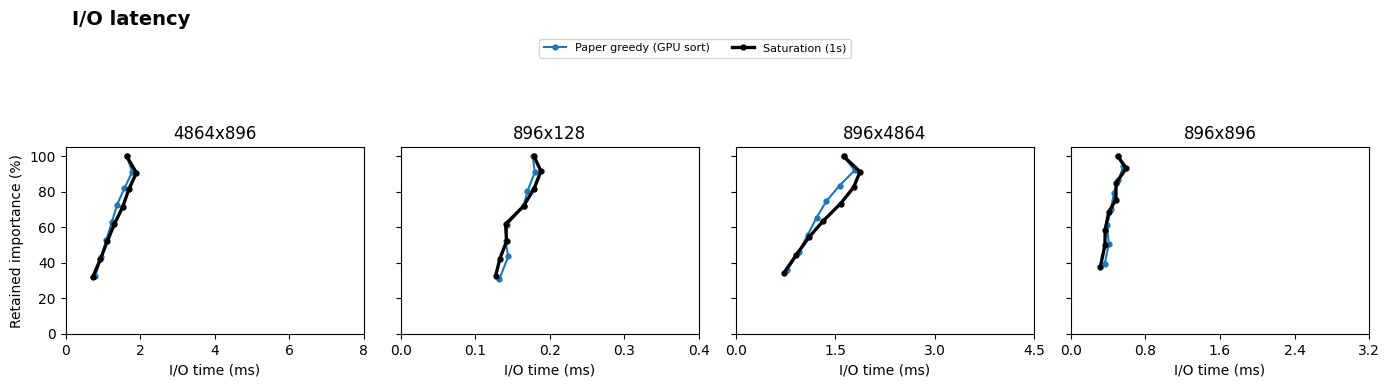

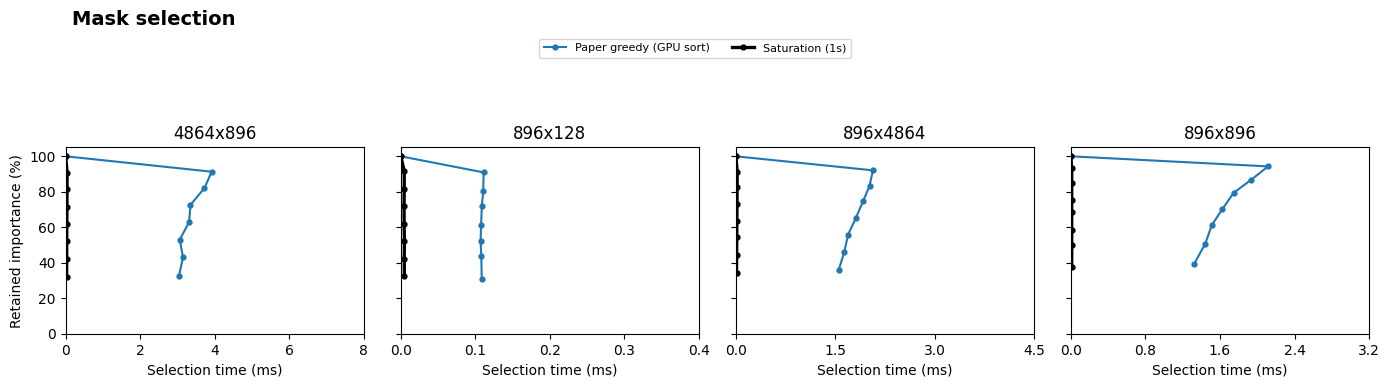

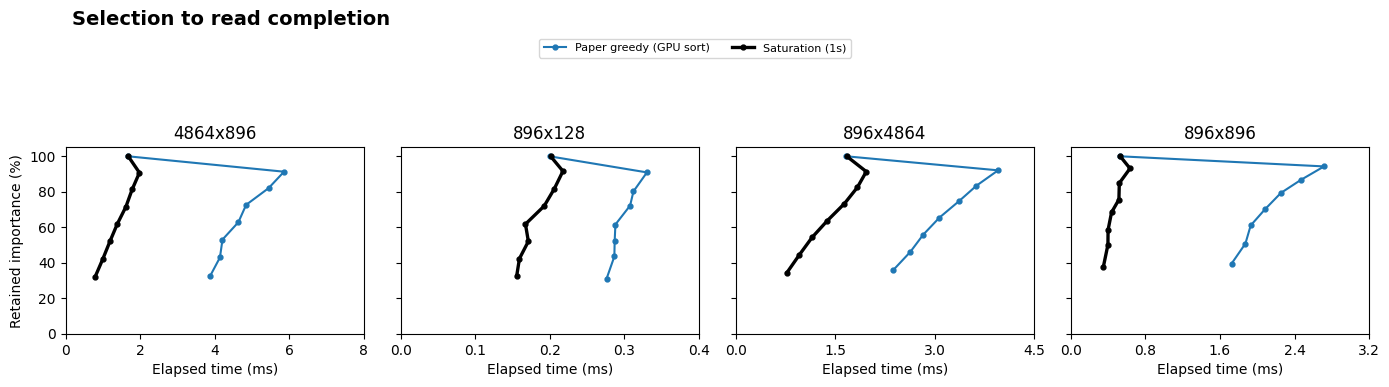

In [36]:
plot_tradeoffs(points, {PAPER: dict(label=PAPER, color="tab:blue"),
                        TILE: dict(label="Saturation (1s)", color="black", linewidth=2.4, zorder=3)})

## Reading the comparison

Subtract Paper from Saturation within each trace and requested budget, then take medians by shape. Negative time differences favor Saturation; positive importance differences mean it retains more importance. Percentage differences are in percentage points. Component medians are not added.

These results describe the time–importance trade-off at the same requested budget, rather than equal accuracy or full-model inference speedup.

In [37]:
paper = cases[cases.method == PAPER]
filled = int(paper.R_selected.eq(paper.R_nominal).sum())
display(Markdown(f"Across **{len(paper):,}** paired trace/budget cases, Paper fills $R$ exactly in "
    f"**{filled:,}**; its median fill is **{paper.fill_pct.median():.2f}%**. "
    "The differences below use the same requested budgets, which may retain different importance."))
paired = cases.set_index(keys + ["method"])[values]
differences = paired.xs(TILE, level="method") - paired.xs(PAPER, level="method")
display(differences.groupby("shape").median().rename(columns={
    "selection_ms": "Δ selection (ms)", "io_ms": "Δ I/O (ms)", "wall_ms": "Δ wall (ms)",
    "retained_pct": "Δ importance (pp)", "fill_pct": "Δ fill (pp)"}).round(4))

Across **1,024** paired trace/budget cases, Paper fills $R$ exactly in **608**; its median fill is **100.00%**. The differences below use the same requested budgets, which may retain different importance.

,Δ selection (ms),Δ I/O (ms),Δ wall (ms),Δ importance (pp),Δ fill (pp)
shape,,,,,
4864x896,-3.1747,0.0288,-3.1562,-0.7722,0.0371
896x128,-0.1026,0.0011,-0.1136,0.1079,1.2102
896x4864,-1.7301,0.0324,-1.6843,-1.1530,0.0000
896x896,-1.5211,-0.0125,-1.5584,-1.4988,0.0000


## Does a different tile size help?

The paired-difference table and scale ranking use only $R<N$: at $R=N$, all scales bypass selection and read the same rows. The curves retain this dense control so they can be compared directly with the first section. For each trace and budget, subtract the result at $s$ from the result at $\alpha s$, then take the median of those paired differences by shape and scale:

$$\Delta t_\alpha=t_\alpha-t_1,\qquad
\Delta q_\alpha=100\bigl(q_\alpha-q_1\bigr).$$

Negative $\Delta t$ means faster; positive $\Delta q$ means more retained importance, in percentage points. The table reports realized tile sizes as well as selection, I/O and wall-time differences. A smaller measured time alone does not establish a better importance–latency trade-off.

In [38]:
missing_scales = [a for name, a in SCALE_METHODS.items() if name not in set(cases.method)]
scale_ready = not missing_scales
if not scale_ready:
    display(Markdown("**Tile-scale sweep not yet measured.** Missing scales: "
        + ", ".join(f"{a:g}s" for a in missing_scales)
        + ". Set `RUN_BENCHMARK = True` on the CUDA-equipped target to measure all methods together. "
          "The saved two-method results cannot determine whether another scale is better."))
else:
    assert {"tile_scale", "tile_kib"} <= set(frame), "Rerun to record scale and realized width."
    expected_scales = frame.method.map(SCALE_METHODS)
    assert frame.tile_scale.fillna(-1).eq(expected_scales.fillna(-1)).all()
    scaled = cases[cases.method.isin(SCALE_METHODS) & (cases.fraction < 1)].copy()
    assert not scaled.empty, "Measure at least one budget below N."
    scaled["scale"] = scaled.method.map(SCALE_METHODS)
    baseline = scaled[scaled.scale == 1].set_index(keys)[values]
    scaled = scaled.join(baseline, on=keys, rsuffix="_s", validate="many_to_one")
    for metric in values:
        scaled[f"delta_{metric}"] = scaled[metric] - scaled[f"{metric}_s"]

Each shape receives its own summary. Repetitions first collapse to a case median; every trace/budget case then has equal weight. The requested scale remains visible even when rounding, a small budget or merged runs produces the same mask.

In [39]:
if scale_ready:
    scale_metrics = ["tile_rows", "tile_kib", "wall_ms", "retained_pct",
                     "delta_selection_ms", "delta_io_ms", "delta_wall_ms", "delta_retained_pct"]
    scale_summary = scaled.groupby(["shape", "scale"])[scale_metrics].median()
    display(scale_summary.rename(columns={
        "tile_rows": "tile rows", "tile_kib": "tile KiB", "wall_ms": "wall (ms)",
        "retained_pct": "importance (%)", "delta_selection_ms": "Δ selection (ms)",
        "delta_io_ms": "Δ I/O (ms)", "delta_wall_ms": "Δ wall (ms)",
        "delta_retained_pct": "Δ importance (pp)"}).round(4))

tile rows  tile KiB  wall (ms)  importance (%)  \
shape    scale                                                   
4864x896 0.25        37.0     64.75     1.4495         63.2744   
         0.50        74.0    129.50     1.3655         62.5336   
         0.75       110.0    192.50     1.3709         62.1344   
         1.00       147.0    257.25     1.3873         61.8214   
         1.25       183.0    320.25     1.4141         61.6895   
         1.50       220.0    385.00     1.4044         61.7355   
         1.75       256.0    448.00     1.2744         61.6475   
         2.00       293.0    512.75     1.4531         61.4208   
896x128  0.25       256.0     64.00     0.1907         63.4709   
         0.50       512.0    128.00     0.1786         62.6650   
         0.75       768.0    192.00     0.1772         61.7638   
         1.00      1024.0    256.00     0.1774         61.7638   
         1.25      1280.0    320.00     0.1780         61.7638   
         1.50      1536.0    384.00     0.1791         61.7638   
         1.75      1792.0    448.00     0.1785         61.7638   
         2.00      2048.0    512.00     0.1783         61.7638   
896x4864 0.25         7.0     66.50     1.3722         66.0103   
         0.50        14.0    133.00     1.3184         64.7974   
         0.75        21.0    199.50     1.3917         64.4937   
         1.00        27.0    256.50     1.3815         63.7286   
         1.25        34.0    323.00     1.3790         63.5266   
         1.50        41.0    389.50     1.4072         63.2013   
         1.75        48.0    456.00     1.2661         63.1066   
         2.00        54.0    513.00     1.3927         62.8455   
896x896  0.25        37.0     64.75     0.4445         71.9100   
         0.50        74.0    129.50     0.4346         71.3455   
         0.75       110.0    192.50     0.4390         70.8220   
         1.00       147.0    257.25     0.4444         69.4645   
         1.25       183.0    320.25     0.4463         68.6057   
         1.50       220.0    385.00     0.4421         69.2260   
         1.75       256.0    448.00     0.4354         69.0003   
         2.00       293.0    512.75     0.4591         67.8924   

                Δ selection (ms)  Δ I/O (ms)  Δ wall (ms)  Δ importance (pp)  
shape    scale                                                                
4864x896 0.25             0.0037      0.0573       0.0641             1.2482  
         0.50             0.0005     -0.0166      -0.0151             0.4848  
         0.75             0.0005     -0.0057      -0.0021             0.1913  
         1.00             0.0000      0.0000       0.0000             0.0000  
         1.25            -0.0005     -0.0011       0.0006            -0.1332  
         1.50            -0.0006     -0.0064      -0.0021            -0.2034  
         1.75            -0.0006     -0.1389      -0.1397            -0.2683  
         2.00            -0.0011      0.0194       0.0197            -0.3480  
896x128  0.25             0.0030      0.0038       0.0078             0.7227  
         0.50             0.0016     -0.0019      -0.0010             0.0000  
         0.75             0.0000     -0.0012      -0.0011             0.0000  
         1.00             0.0000      0.0000       0.0000             0.0000  
         1.25             0.0000     -0.0004      -0.0001             0.0000  
         1.50            -0.0001      0.0002       0.0005             0.0000  
         1.75            -0.0000     -0.0000       0.0008             0.0000  
         2.00            -0.0000     -0.0001       0.0001             0.0000  
896x4864 0.25             0.0034      0.0369       0.0384             1.7323  
         0.50             0.0010     -0.0060      -0.0071             0.7229  
         0.75             0.0005     -0.0133      -0.0149             0.3547  
         1.00             0.0000      0.0000       0.0000             0.0000  
         1.25            -0.0004 

The same three views compare all eight tile scales: I/O time, mask selection, and selection-to-read completion against retained importance. Each point is the median across traces at one requested budget, including the all-rows control. Points and axis ranges are shared with the Paper comparison, and the bold black $1s$ curve is identical. Colors follow scale order. Curves connect increasing budgets; they do not interpolate an equal-importance speedup.

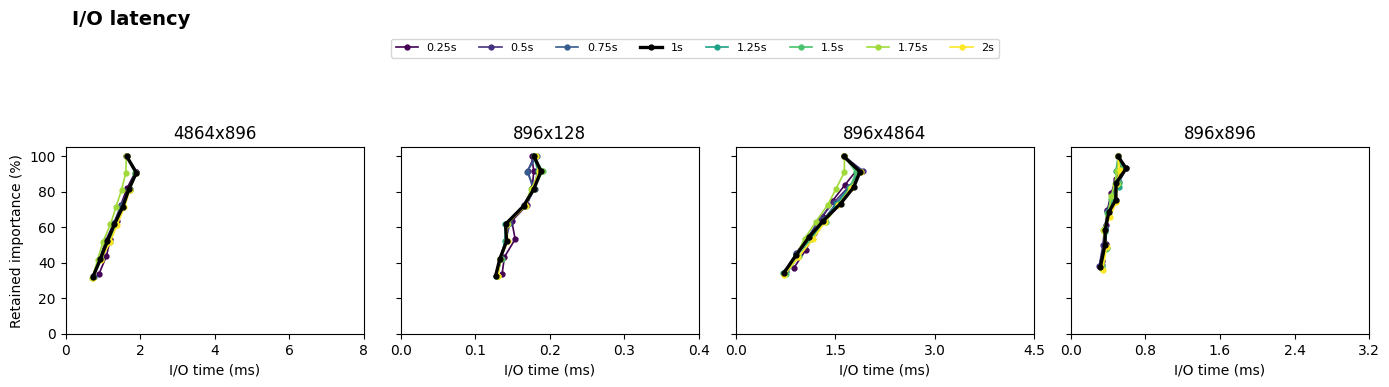

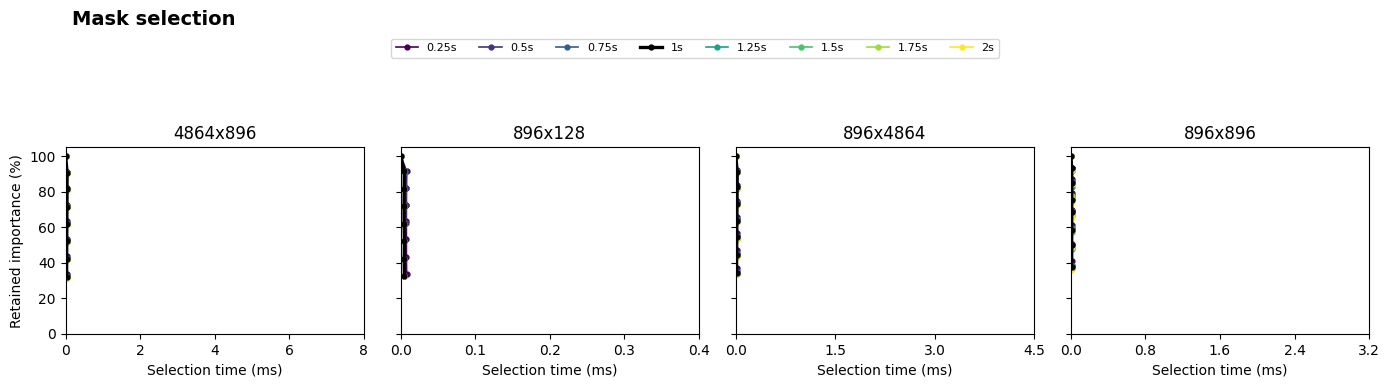

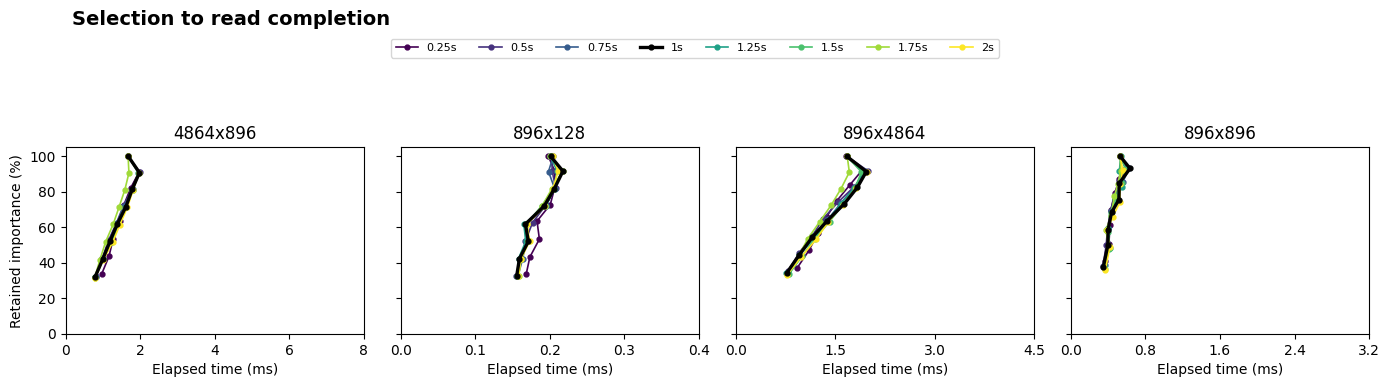

In [40]:
if scale_ready:
    scale_points = all_points[all_points.method.isin(SCALE_METHODS)]
    pd.testing.assert_frame_equal(points[points.method == TILE], scale_points[scale_points.method == TILE])
    colors = plt.get_cmap("viridis")(np.linspace(0, 1, len(SCALE_METHODS)))
    styles = {name: dict(label=f"{a:g}s", color=color, linewidth=1.2)
              for (name, a), color in zip(SCALE_METHODS.items(), colors)}
    styles[TILE].update(color="black", linewidth=2.4, zorder=3)
    plot_tradeoffs(scale_points, styles)

### Selected channels at the same budget

The mask view places all eight scales on the same channel axis. Yellow marks selected rows and purple marks omitted rows; the labels report selected rows and merged runs. It reconstructs the recorded intervals, without rerunning selection or reading the activation archive.

By default, use the lowest recorded trace ID and the measured fraction nearest 0.5 (the smaller fraction breaks a tie). Change `MASK_TRACE_ID` or `MASK_FRACTION` below to inspect another case. This is an illustration of contiguity, not an aggregate result.

In [41]:
MASK_TRACE_ID, MASK_FRACTION = None, 0.5
if scale_ready:
    pool = frame[frame.method.isin(SCALE_METHODS) & (frame.fraction < 1)]
    trace_id = pool.trace_id.min() if MASK_TRACE_ID is None else MASK_TRACE_ID
    sample = pool[pool.trace_id == trace_id]
    assert not sample.empty, "Choose a recorded trace ID."
    fraction = min(sample.fraction.unique(), key=lambda f: (abs(f-MASK_FRACTION), f))
    sample = sample[sample.fraction == fraction]
    assert sample.groupby("method").intervals.nunique().eq(1).all(), "Masks differ across repetitions."
    example = sample.drop_duplicates("method").set_index("method").loc[list(SCALE_METHODS)]
    assert example[["shape", "R_nominal"]].nunique().eq(1).all()
    shape, R = example["shape"].iloc[0], int(example.R_nominal.iloc[0])
    N = int(shape.split("x")[0])

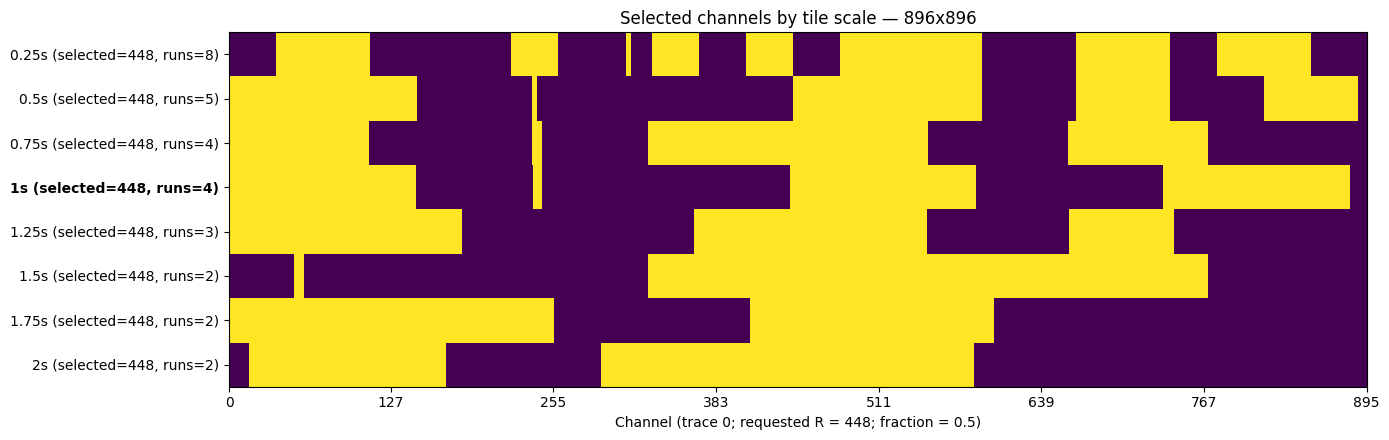

In [42]:
if scale_ready:
    masks = np.zeros((len(example), N), dtype=np.uint8)
    labels = []
    for row, (name, data) in enumerate(example.iterrows()):
        spans = json.loads(data.intervals)
        for start, end in spans:
            assert 0 <= start < end <= N
            masks[row, start:end] = 1
        assert int(masks[row].sum()) == int(data.R_selected) == R
        labels.append(f"{SCALE_METHODS[name]:g}s (selected={int(data.R_selected)}, runs={len(spans)})")
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.imshow(masks, aspect="auto", interpolation="nearest", cmap="viridis", vmin=0, vmax=1)
    ax.set(yticks=np.arange(len(labels)), yticklabels=labels,
           xticks=np.unique(np.linspace(0, N-1, min(8, N), dtype=int)),
           xlabel=f"Channel (trace {trace_id}; requested R = {R}; fraction = {fraction:g})",
           title=f"Selected channels by tile scale — {shape}")
    ax.get_yticklabels()[list(SCALE_METHODS).index(TILE)].set_fontweight("bold")
    fig.tight_layout()
    plt.show()

## Reading the scale sweep

The text below identifies the scale(s) with the lowest median wall time in each shape and reports their paired importance change. This is a descriptive comparison over the measured traces and budgets, not a significance test or a universally optimal scale. Near ties can change between runs. A favorable $s$ in the isolated-read profile does not guarantee a favorable $B_1$ after selection, merging and threaded reads.

In [43]:
if scale_ready:
    findings = []
    for shape, group in scale_summary.groupby(level="shape"):
        group = group.droplevel("shape")
        fastest = group[group.wall_ms == group.wall_ms.min()]
        for a, row in fastest.iterrows():
            importance = (f"{row.delta_retained_pct:+.3f} pp"
                          if pd.notna(row.delta_retained_pct) else "undefined (zero total importance)")
            findings.append(f"- **{shape}**: **{a:g}s** has the lowest median wall time "
                f"(**{row.wall_ms:.4f} ms**). Paired changes from $s$: "
                f"**{row.delta_wall_ms:+.4f} ms** wall time and **{importance}** importance.")
    display(Markdown("\n".join(findings)))

- **4864x896**: **1.75s** has the lowest median wall time (**1.2744 ms**). Paired changes from $s$: **-0.1397 ms** wall time and **-0.268 pp** importance.
- **896x128**: **0.75s** has the lowest median wall time (**0.1772 ms**). Paired changes from $s$: **-0.0011 ms** wall time and **+0.000 pp** importance.
- **896x4864**: **1.75s** has the lowest median wall time (**1.2661 ms**). Paired changes from $s$: **-0.1005 ms** wall time and **-0.543 pp** importance.
- **896x896**: **0.5s** has the lowest median wall time (**0.4346 ms**). Paired changes from $s$: **-0.0053 ms** wall time and **+0.876 pp** importance.